<a href="https://colab.research.google.com/github/Rajesh2015/Neural-Networks-Projects/blob/main/CNN%20Projects/Face_Recognization_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision Face Recogonition


## Part A :Build Face Detection System

In [1]:
# System and utility libraries
import os                      # For file/directory operations
import sys                     # System-level functions
import random                  # Random number generation
import math                    # Mathematical operations

# Data handling
import numpy as np             # Numerical operations
import pandas as pd            # Data manipulation (DataFrames)

# Image processing
import cv2                     # OpenCV for image operations
import matplotlib.pyplot as plt      # Plotting images and charts
import matplotlib.image as mpimg     # Reading images using matplotlib

# Machine learning - Scikit-learn
from sklearn.model_selection import train_test_split       # Train/test split
from sklearn.preprocessing import LabelEncoder             # Encode labels to integers
from sklearn.preprocessing import StandardScaler           # Feature normalization
from sklearn.decomposition import PCA                      # Dimensionality reduction
from sklearn.svm import SVC                                # Support Vector Classifier
from sklearn.metrics import accuracy_score                 # Accuracy evaluation

# Deep Learning - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import backend                       # Backend utilities (e.g., for custom loss)
from tensorflow.keras.models import Sequential, Model, load_model  # Model building and loading
from tensorflow.keras.optimizers import Adam               # Optimizer
from tensorflow.keras.callbacks import (                   # Training callbacks
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

# Keras layers for CNNs, U-Nets, etc.
from keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate,
    Conv2DTranspose, BatchNormalization, Dropout, Flatten,
    Activation, Convolution2D, Lambda, SpatialDropout2D,
    ZeroPadding2D
)

# Keras pretrained models
from tensorflow.keras.applications import (
    EfficientNetB0, MobileNetV2
)
from tensorflow.keras.applications.resnet import (
    ResNet50, preprocess_input
)

#Loss functions (if needed for custom models)
from tensorflow.python.keras import losses


### UTILS

In [2]:
def show_image_and_mask_side_by_side(img_arr,mask_arr,model=None):
    """
    Visualizes a sample image, its true mask (label), and optionally the predicted mask.

    Parameters:
    -----------
    img_arr : numpy.ndarray
    mask_arr : numpy.ndarray


    model :  optional (default=None)
    Displays:
    ---------
    A matplotlib figure with:
      - Original input image
      - Ground truth mask
      - Predicted mask (if show_prediction=True)
    """

    if model:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

    ax1.imshow(img_arr)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(mask_arr)
    ax2.set_title("Original Mask")
    ax2.axis("off")

    if model:
        prediction = model.predict(img_arr.reshape(1, 224, 224, 3))[0]
        ax3.imshow(prediction)
        ax3.set_title("Predicted Mask")
        ax3.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
def augment_np(image, mask):
    """
    Augments a numpy image and mask.
    Parameters:
    -----------
    image : numpy.ndarray
    mask : numpy.ndarray
    Returns:
    --------
    image : numpy.ndarray
    mask : numpy.ndarray
    """
    # Convert to tensors
    image = tf.convert_to_tensor(image)
    mask = tf.convert_to_tensor(mask)

    # Make sure mask has shape (H, W, 1)
    if mask.ndim == 2:
        mask = tf.expand_dims(mask, axis=-1)

    # Apply same augmentations to both
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Return as NumPy arrays
    return image.numpy(), tf.squeeze(mask).numpy()

In [4]:
def set_seeds(seed=42):
  """
  Sets the seeds for reproducibility.
  Parameters:
  -----------
  seed : int, default=42
  """
  os.environ['PYTHONHASHSEED'] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)

In [5]:
def show_prediction_overlay(image, mask, idx=0, alpha=0.4, resize_to=(128, 128)):
    """
    Displays original image and predicted mask overlay side by side.

    Parameters:
    - image: array of test images (e.g., X_test)
    - mask: array of predicted masks (e.g., pred_test)
    - idx: index of the image to display
    - alpha: transparency of the mask overlay
    - resize_to: size to downscale the images (width, height)
    """
    img = image[idx]
    pred = (mask[idx] > 0.5).astype(np.uint8).squeeze()

    # Resize image and prediction
    img_resized = cv2.resize(img, resize_to)
    if pred.ndim == 2:
        pred_resized = cv2.resize(pred, resize_to, interpolation=cv2.INTER_NEAREST)
    else:
        pred_resized = cv2.resize(pred[..., 0], resize_to, interpolation=cv2.INTER_NEAREST)

    # Create overlay
    overlay = img_resized.copy()
    color = [255, 0, 0]  # Red overlay
    for c in range(3):
        overlay[..., c] = np.where(pred_resized == 1,
                                   overlay[..., c] * (1 - alpha) + alpha * color[c],
                                   overlay[..., c])

    # Plot
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized.astype(np.uint8))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Read data

In [8]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Load numpy array
data = np.load('/content/drive/MyDrive/Python Course_shared/computer Vision/Images.npy', allow_pickle=True)

In [10]:
# print Shape
data.shape

(393, 2)

### Observations:
There are around 393 Images loaded

In [11]:
# Show the data
data[:2]

array([[array([[[42, 37, 34],
                [56, 51, 48],
                [71, 66, 63],
                ...,
                [23, 33, 34],
                [26, 36, 37],
                [28, 38, 39]],

               [[40, 35, 32],
                [51, 46, 43],
                [64, 59, 56],
                ...,
                [27, 36, 35],
                [24, 33, 32],
                [26, 35, 34]],

               [[43, 38, 35],
                [51, 46, 43],
                [61, 56, 53],
                ...,
                [28, 30, 27],
                [33, 35, 32],
                [35, 37, 34]],

               ...,

               [[56, 47, 40],
                [57, 48, 41],
                [61, 52, 45],
                ...,
                [67, 48, 42],
                [55, 35, 28],
                [60, 40, 33]],

               [[53, 44, 37],
                [54, 45, 38],
                [57, 48, 41],
                ...,
                [59, 40, 34],
                [60, 40, 3

In [12]:
# Show the metadata
data[0][1]

[{'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
   {'x': 0.1723076923076923, 'y': 0.45345345345345345}],
  'imageWidth': 650,
  'imageHeight': 333},
 {'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.583076923076923, 'y': 0.2912912912912913},
   {'x': 0.6584615384615384, 'y': 0.46846846846846846}],
  'imageWidth': 650,
  'imageHeight': 333}]

### Observations
Second column contains metadata of image like label height width and lower bound upper bound of image

##### Show Some Image

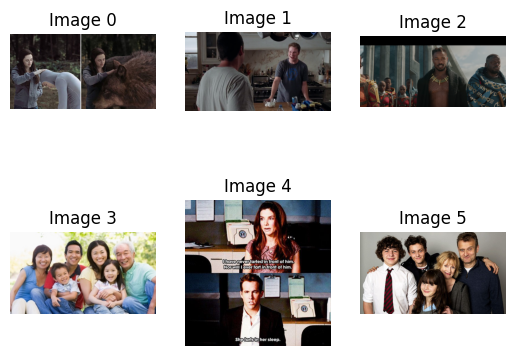

In [13]:
# Show first 5 images
for index in range(0,6,1):
    plt.subplot(2, 3, index + 1)  # Create a 2-row, 3-column grid  plt.imshow(data[index][0])
    plt.imshow(data[index][0])  # Show the image
    plt.axis("off")  # Hide axes
    plt.title(f"Image {index}")  # Add a title

Images are shown properly

##### Find out Image which have more then 3 channels

In [ ]:
for index in range(data.shape[0]):
    img = data[index][0]  # Extract the image

    if len(img.shape) == 2:
        print(f"Image {index} is grayscale (shape: {img.shape})")
    elif img.shape[2] == 4:
        print(f"Image {index} has an alpha channel (RGBA) (shape: {img.shape})")
    elif img.shape[2] != 3:
        print(f"Image {index} has an unexpected number of channels: {img.shape}")

Image 1 has an alpha channel (RGBA) (shape: (697, 1280, 4))
Image 2 has an alpha channel (RGBA) (shape: (291, 600, 4))
Image 39 has an alpha channel (RGBA) (shape: (340, 516, 4))
Image 47 has an alpha channel (RGBA) (shape: (600, 800, 4))
Image 62 has an alpha channel (RGBA) (shape: (312, 750, 4))
Image 134 has an alpha channel (RGBA) (shape: (330, 538, 4))
Image 145 has an alpha channel (RGBA) (shape: (496, 860, 4))
Image 237 has an alpha channel (RGBA) (shape: (379, 505, 4))
Image 251 has an alpha channel (RGBA) (shape: (400, 770, 4))
Image 260 is grayscale (shape: (350, 650))
Image 325 has an alpha channel (RGBA) (shape: (267, 740, 4))
Image 335 has an alpha channel (RGBA) (shape: (281, 600, 4))


### Observations:
Some images have 4 channel and some have 2 channel

In [15]:
# Define height and width
IMAGE_HEIGHT=224
IMAGE_WIDTH=224

In [16]:
# Define masks and image with background as black
masks = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
image = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)

for index in range(data.shape[0]):
    img = data[index][0]

    # Resize first
    img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_CUBIC)

    # Normalize channels: make sure image has exactly 3 channels
    if img.ndim == 2:  # grayscale
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[2] < 3:
        # Pad missing channels with zeros
        pad = np.zeros((img.shape[0], img.shape[1], 3 - img.shape[2]), dtype=img.dtype)
        img = np.concatenate((img, pad), axis=-1)
    elif img.shape[2] > 3:
        img = img[:, :, :3]  # Take only first 3 channels

    image[index] = img

    # Create the mask from annotation
    for box in data[index][1]:
        x1 = int(box["points"][0]['x'] * IMAGE_WIDTH)
        y1 = int(box["points"][0]['y'] * IMAGE_HEIGHT)
        x2 = int(box["points"][1]['x'] * IMAGE_WIDTH)
        y2 = int(box["points"][1]['y'] * IMAGE_HEIGHT)

        # Clamp to valid range
        x1, x2 = max(0, x1), min(IMAGE_WIDTH, x2)
        y1, y2 = max(0, y1), min(IMAGE_HEIGHT, y2)

        masks[index][y1:y2, x1:x2] = 1


In [17]:
# Divide in train and test set 80% training and 20% testing
size=math.ceil(image.shape[0] * 80 / 100)
print(f"Training {size} and Test Size {image.shape[0]-size}")
X_train=image[:size]
y_train=masks[:size]
X_test=image[size:]
y_test=masks[size:]

Training 315 and Test Size 78


### Observations:
We have total 315 images in training and 78 in testing

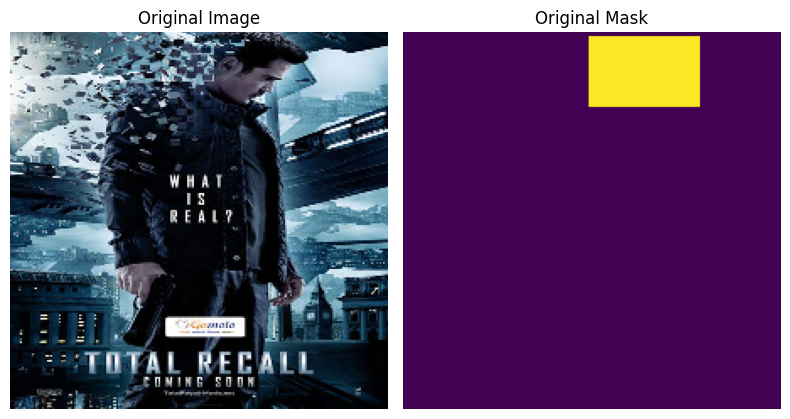

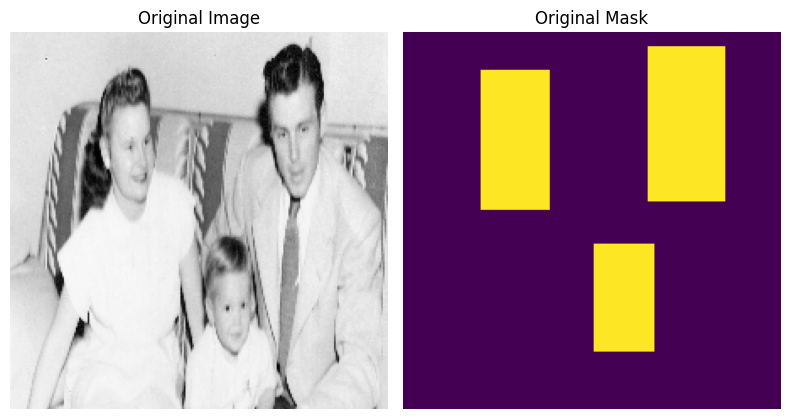

In [19]:
# Show some images from train data and its mask
import random
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])


###Observations:
We can see the mask are generated aroudn face

### Model Building
- Addding ResNet as model with below parameter values
        input_shape: IMAGE_HEIGHT, IMAGE_WIDTH, 3
        include_top: False
        weights: "imagenet"
- UNET architecture layers


#### Custom Loss function

In [23]:
from tensorflow.keras import backend as K

def dice_coeff(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

Resnet50 Model Creation

In [ ]:
def unet_resnet50(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load ResNet50 with pretrained weights, exclude top layers
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    # Freeze encoder if desired
    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Extract skip connections
    skips = [
        base_model.get_layer("conv1_relu").output,    # 112x112
        base_model.get_layer("conv2_block3_out").output, # 56x56
        base_model.get_layer("conv3_block4_out").output, # 28x28
        base_model.get_layer("conv4_block6_out").output  # 14x14
    ]
    encoder_output = base_model.get_layer("conv5_block3_out").output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling to match original input size
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    x = Conv2D(1, (1, 1), activation='sigmoid')(x)  # For binary segmentation

    return Model(inputs, x)

In [ ]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train = tf.keras.applications.resnet.preprocess_input(X_train.astype('float32'))
X_resNet_test = tf.keras.applications.resnet.preprocess_input(X_test.astype('float32'))

In [ ]:
set_seeds(43)
unet_resnet50_model = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_resnet50_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 85,819,841 (327.38 MB)

 Trainable params: 62,232,129 (237.40 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 ### Observations:
 Total params: 85,819,841 (327.38 MB) out of which
 Trainable params: 62,232,129 (237.40 MB)


In [ ]:
# Created Unet model with backbone as resnet 50
unet_resnet50_model.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])

In [ ]:
# Print shapes of xtrain_resent after pre processing
print("X shape:", X_resNet_train.shape)
print("masks shape:", y_train.shape)

X shape: (315, 224, 224, 3)
masks shape: (315, 224, 224)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Any NaNs in y_train?", np.isnan(y_train).any())
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

X_train shape: (315, 224, 224, 3)
y_train shape: (315, 224, 224)
Any NaNs in X_train? False
Any NaNs in y_train? False
X_train dtype: uint8
y_train dtype: uint8


### Observations:
No nana value in training set

In [ ]:
# Create checkpoint and early stopping and ReduceLROnPlateau as callback
checkpoint = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")


In [ ]:
# Train model
unet_resnet50_model.fit(X_train, y_train, epochs=10, batch_size=8, callbacks=[checkpoint, reduce_lr, stop])

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - dice_coeff: 0.1452 - dice_loss: 0.8548 - loss: 1.3729
Epoch 1: loss improved from inf to 1.23940, saving model to model-1.24.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - dice_coeff: 0.1465 - dice_loss: 0.8535 - loss: 1.3697 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - dice_coeff: 0.3775 - dice_loss: 0.6225 - loss: 0.9685
Epoch 2: loss improved from 1.23940 to 0.86881, saving model to model-0.87.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - dice_coeff: 0.3792 - dice_loss: 0.6208 - loss: 0.9660 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coeff: 0.5233 - dice_loss: 0.4767 - loss: 0.7645
Epoch 3: loss improved from 0.86881 to 0.70049, saving model to model-0.70.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - dice_coeff: 0.5242 - dice_loss: 0.4758 - loss: 0.7629 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - dice_coeff:

In [ ]:
# Evaluate the model.
result_score = unet_resnet50_model.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - dice_coeff: 0.6059 - dice_loss: 0.3941 - loss: 0.6671
Test Loss: 0.7270
Dice Loss: 0.4338
Dice Coefficient: 0.5662


### Observation:
Model performance for test is around .56 which is ok but we will try to improve on this further

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


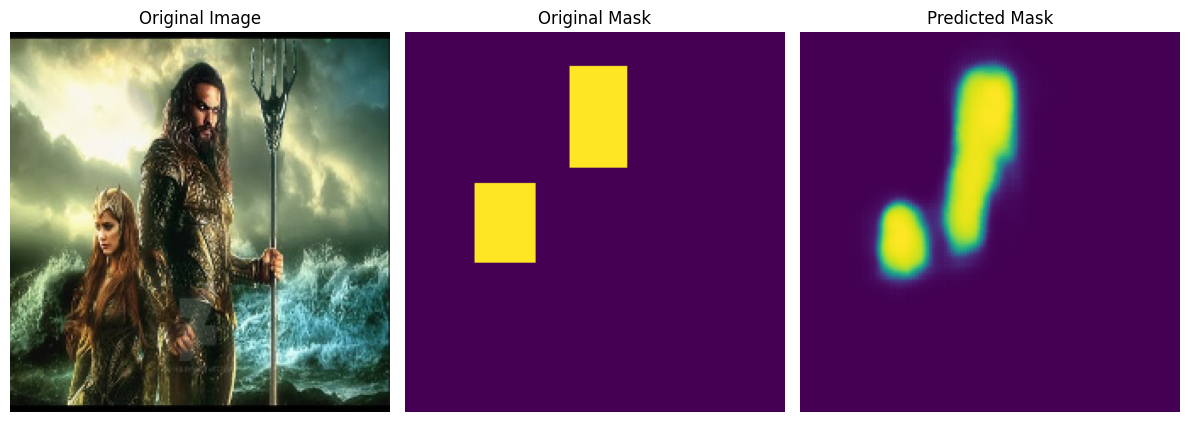

In [ ]:
show_image_and_mask_side_by_side(X_test[1],y_test[1],unet_resnet50_model)

####  Data Augomentation


Image Augomentation and Model Creation .We apply data augomentation only on training not testing

In [ ]:
# Create augomneted image
X_train_aug = []
y_train_aug = []

for img, mask in zip(X_train, y_train):

    augmented_img, augmented_mask = augment_np(img, mask)
    X_train_aug.append(augmented_img)
    y_train_aug.append(augmented_mask)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

# concat autogmented image with initial x_train and y_train to have more training set
X_train_full = np.concatenate([X_train, X_train_aug], axis=0)
y_train_full = np.concatenate([y_train, y_train_aug], axis=0)

In [ ]:
# show shape of x_train
X_train_full.shape

(630, 224, 224, 3)

### Observations:
We have around 630 training set after data augomentation

In [ ]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train_full = tf.keras.applications.resnet.preprocess_input(X_train_full.astype('float32'))


#### Training with augumented data. We have increased the batch size as well to 20

In [ ]:
# Clear any previous models from memory (useful before training a new model)
backend.clear_session()

# Set random seed for reproducibility
set_seeds(43)

#Define training callbacks

# Save model weights with best (lowest) training loss
checkpoint2 = ModelCheckpoint(
    "model-{loss:.2f}.weights.h5",   # File naming pattern with loss value
    monitor="loss",                  # Monitor training loss
    verbose=1,                       # Print updates during training
    save_best_only=True,            # Only save if the model improved
    save_weights_only=True,         # Save only the weights (not full model)
    mode="min"                       # Looking to minimize the loss
)

# Stop training early if loss does not improve for 5 epochs
stop2 = EarlyStopping(
    monitor="loss",
    patience=5,     # Number of epochs with no improvement
    mode="min"
)

# Reduce learning rate if loss plateaus
reduce_lr2 = ReduceLROnPlateau(
    monitor="loss",
    factor=0.2,       # Reduce LR by a factor of 0.2
    patience=5,       # Wait 5 epochs before reducing
    min_lr=1e-6,      # Minimum learning rate limit
    verbose=1,
    mode="min"
)

# Initialize model
unet_resnet50_model_2 = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))

# Compile model with custom loss and metrics
unet_resnet50_model_2.compile(
    loss=bce_dice_loss,           # Combined Binary Crossentropy + Dice loss
    optimizer='adam',             # Adam optimizer
    metrics=[dice_loss, dice_coeff]  # Evaluation metrics
)

# Train model on training data
unet_resnet50_model_2.fit(
    X_resNet_train_full,          # Training images
    y_train_full,                 # Ground truth masks
    epochs=10,                    # Number of epochs
    batch_size=20,                # Batch size
    callbacks=[checkpoint2, reduce_lr2, stop2]  # Training callbacks
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - dice_coeff: 0.1849 - dice_loss: 0.8151 - loss: 1.3494
Epoch 1: loss improved from inf to 1.20812, saving model to model-1.21.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - dice_coeff: 0.1862 - dice_loss: 0.8138 - loss: 1.3451 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - dice_coeff: 0.4237 - dice_loss: 0.5763 - loss: 0.8962
Epoch 2: loss improved from 1.20812 to 0.90575, saving model to model-0.91.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - dice_coeff: 0.4238 - dice_loss: 0.5762 - loss: 0.8965 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - dice_coeff: 0.4183 - dice_loss: 0.5817 - loss: 0.8895
Epoch 3: loss improved from 0.90575 to 0.82512, saving model to model-0.83.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - dice_coeff: 0.4201 - dice_loss: 0.5799 - loss: 0.8875 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - dice_coef

In [ ]:
# Evaluate the model.
result_score = unet_resnet50_model_2.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - dice_coeff: 0.6419 - dice_loss: 0.3581 - loss: 0.5549
Test Loss: 0.5938
Dice Loss: 0.3895
Dice Coefficient: 0.6105


### Observations:
- We could able to improve the dice coeff to **.61**  from **.56** after data augomentaion.Model is good no sign of overfitting.
-  It is little bit slower though we will try some light weight and less deep model.

#### Base Model :MobilenetV2

In [20]:
def unet_mobilenetv2(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load MobileNetV2 as encoder
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Skip connections
    skips = [
        base_model.get_layer('block_1_expand_relu').output,   # 112x112
        base_model.get_layer('block_3_expand_relu').output,   # 56x56
        base_model.get_layer('block_6_expand_relu').output,   # 28x28
        base_model.get_layer('block_13_expand_relu').output   # 14x14
    ]
    encoder_output = base_model.get_layer('block_16_project').output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling and output
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(x)

    return Model(inputs, outputs)


In [21]:
X_mobilenet_train = tf.keras.applications.mobilenet_v2.preprocess_input(X_train.astype('float32'))
X_mobilenet_test = tf.keras.applications.mobilenet_v2.preprocess_input(X_test.astype('float32'))

In [24]:
# Clear previous models from memory
backend.clear_session()
set_seeds(43)  # Set random seed for reproducibility

# Define training callbacks
checkpoint2 = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1,
                              save_best_only=True, save_weights_only=True, mode="min")  # Save best model
stop2 = EarlyStopping(monitor="loss", patience=5, mode="min")  # Stop early if no improvement
reduce_lr2 = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5,
                               min_lr=1e-6, verbose=1, mode="min")  # Reduce LR on plateau

# Build and compile the model
unet_mobilev2_model = unet_mobilenetv2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_mobilev2_model.compile(loss=bce_dice_loss, optimizer='adam', metrics=[dice_loss, dice_coeff])  # Compile with loss & metrics
# Show summary
unet_mobilev2_model.summary()


<ipython-input-20-a933a025269a>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 15,689,873 (59.85 MB)

 Trainable params: 13,847,889 (52.83 MB)

 Non-trainable params: 1,841,984 (7.03 MB)

We have reduced the trainable parameters to 13 million from 23 million of resnet50.This is a small model and might be faster as well.

In [25]:
# Train the model
unet_mobilev2_model.fit(X_mobilenet_train, y_train, epochs=25, batch_size=8,
                        callbacks=[checkpoint2, reduce_lr2, stop2])

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - dice_coeff: 0.1431 - dice_loss: 0.8569 - loss: 1.3407
Epoch 1: loss improved from inf to 1.26379, saving model to model-1.26.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 569ms/step - dice_coeff: 0.1435 - dice_loss: 0.8565 - loss: 1.3389 - learning_rate: 0.0010
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - dice_coeff: 0.2070 - dice_loss: 0.7930 - loss: 1.1719
Epoch 2: loss improved from 1.26379 to 1.13975, saving model to model-1.14.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - dice_coeff: 0.2076 - dice_loss: 0.7924 - loss: 1.1711 - learning_rate: 0.0010
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - dice_coeff: 0.2197 - dice_loss: 0.7803 - loss: 1.1928
Epoch 3: loss improved from 1.13975 to 1.06161, saving model to model-1.06.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - dice_coeff: 0.2218 - dice_loss: 0.7782 - loss: 1.1896 - learning_rate: 0.0010
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - dic

Observations:
The model seems to be run Faster then Resnet50 and Dice Coefficeint is at .76

In [26]:
# Evaluate model on DC
result_score = unet_mobilev2_model.evaluate(X_mobilenet_test, y_test, batch_size=8, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - dice_coeff: 0.6881 - dice_loss: 0.3119 - loss: 0.5093
Test Loss: 0.5162
Dice Loss: 0.3161
Dice Coefficient: 0.6839


### Observations:
This is better then even Resnet50 with augomented dataset with Test a Dice Coefficinet of .68

## 🔍 Model Evaluation Summary

| Model                | Test Loss | Dice Loss | Dice Coefficient |
|---------------------|-----------|-----------|------------------|
| **ResNet50 (No Aug)**   | 0.7270    | 0.4338    | 0.5662           |
| **ResNet50 (With Aug)** | 0.5938    | 0.3895    | 0.6105           |
| **MobileNetV2**         | 0.5162    | 0.3161    | 0.6839           |

> **Observation:**  
- Data augmentation improved ResNet50 performance.  
- MobileNetV2 outperformed both ResNet versions with the best Dice Coefficient of **0.6839**.

- We will use MobilenetV2 backbone model for our next steps and mask detection as its afster to train and even have higher Dice Coefficient


In [ ]:
# Run predcition
pred_test= unet_mobilev2_model.predict(X_mobilenet_test, verbose=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


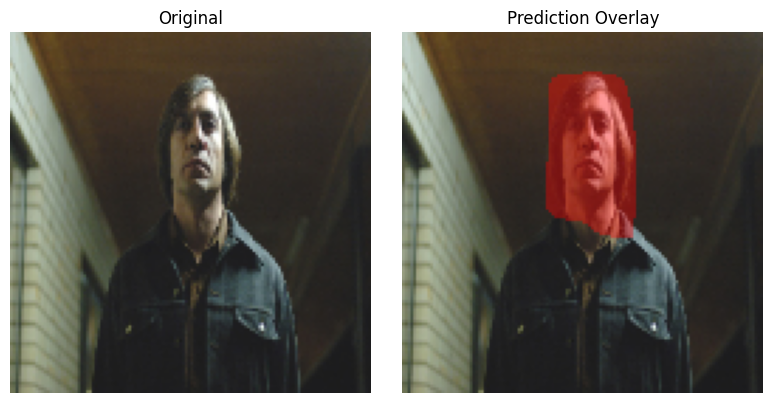

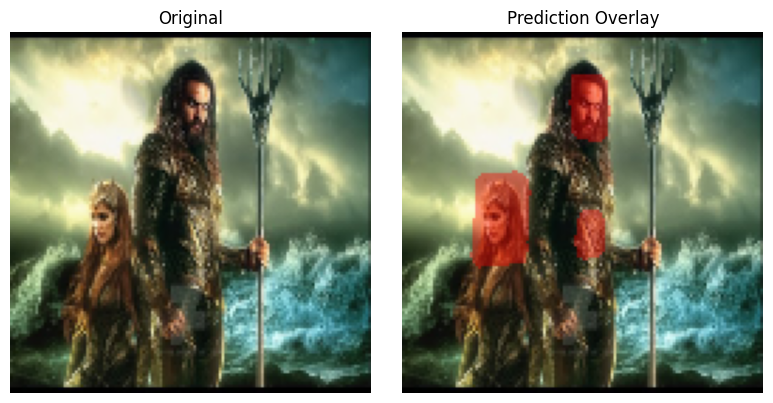

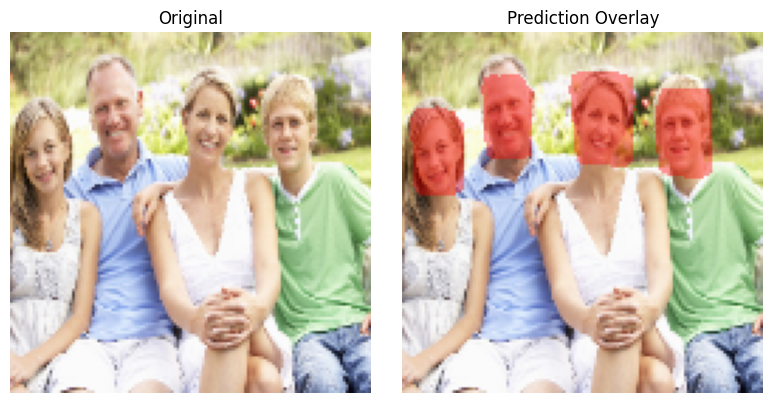

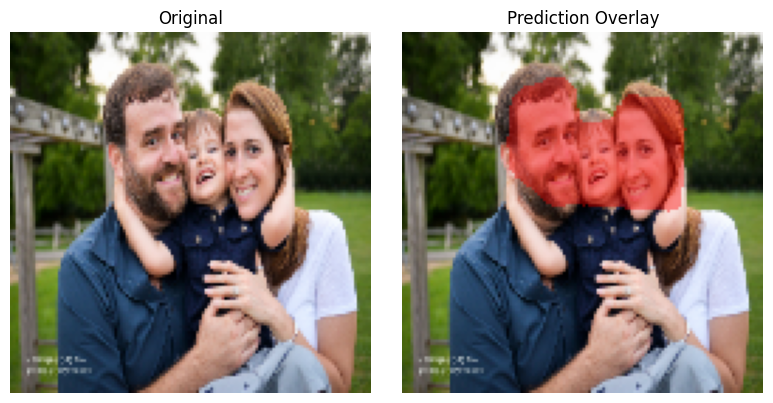

In [ ]:
# Preduct for first 4 test images
for index in range(4):
    show_prediction_overlay(X_test, pred_test, idx=index)

### Obsevations:
 - Face mask are overlayed on image nicely .
 - Overall Mobile net took less compute and perform well

## PART B : To create image dataset which need to be used by AI team to build image classifier data

#### We will use MobileNetV2 backbone model for this Part B

In [27]:
# Unzip the images
!unzip '/content/drive/MyDrive/Python Course_shared/computer Vision/training_images-20211126T092819Z-001.zip'

Archive:  /content/drive/MyDrive/Python Course_shared/computer Vision/training_images-20211126T092819Z-001.zip
  inflating: training_images/real_00947.jpg  
  inflating: training_images/real_01052.jpg  
  inflating: training_images/real_01042.jpg  
  inflating: training_images/real_00964.jpg  
  inflating: training_images/real_01053.jpg  
  inflating: training_images/real_00971.jpg  
  inflating: training_images/real_01057.jpg  
  inflating: training_images/real_01044.jpg  
  inflating: training_images/real_01041.jpg  
  inflating: training_images/real_01067.jpg  
  inflating: training_images/real_00969.jpg  
  inflating: training_images/real_00956.jpg  
  inflating: training_images/real_00975.jpg  
  inflating: training_images/real_01021.jpg  
  inflating: training_images/real_00945.jpg  
  inflating: training_images/real_01068.jpg  
  inflating: training_images/real_01062.jpg  
  inflating: training_images/real_01016.jpg  
  inflating: training_images/real_01065.jpg  
  inflating: tr

In [28]:
image_folder = '/content/training_images/'
image_files = os.listdir(image_folder)

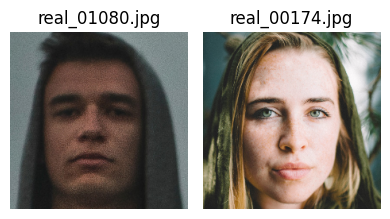

In [29]:
# Show some images from the unzipped folder
fig, axes = plt.subplots(1, 2, figsize=(4, 5))  # 1 row, 2 columns

for i, file in enumerate(image_files[:2]):
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(file)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


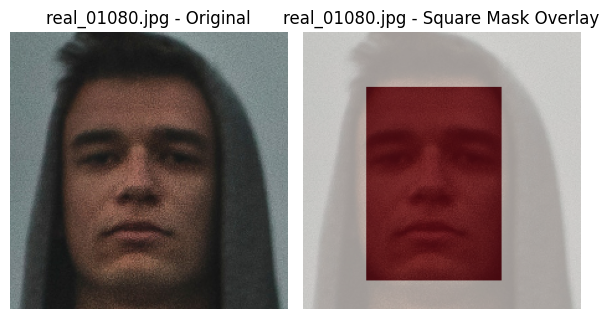

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


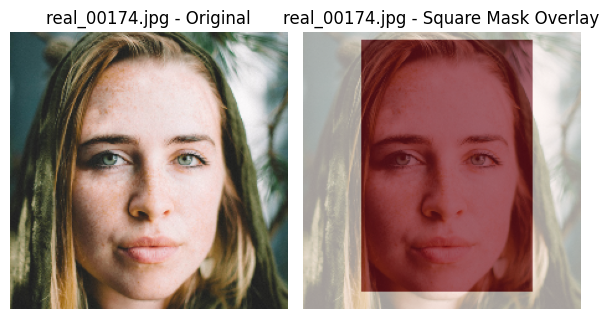

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


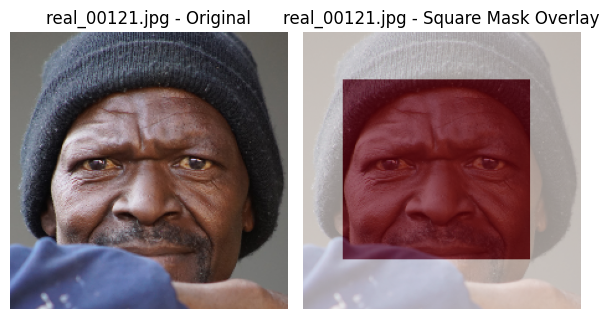

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


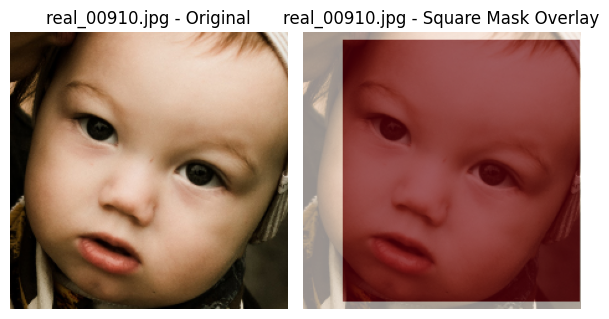

In [35]:
# Loop through first 4 images
for i, file in enumerate(image_files[:4]):
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue  # Skip if image not loaded

    original_size = img.shape[:2]  # Store original image size (height, width)

    # Resize and convert to RGB
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Normalize and prepare input
    img_input = img_resized / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    # Predict mask and threshold
    pred_mask = unet_mobilev2_model.predict(img_input)[0]
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # Resize predicted mask for visualization
    pred_mask_resized = cv2.resize(pred_mask, (224, 224))

    # Get contours and draw bounding rectangle as square mask
    contours, _ = cv2.findContours(pred_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    square_mask = np.zeros_like(pred_mask_resized)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        cv2.rectangle(square_mask, (x, y), (x + w, y + h), 1, -1)  # Draw filled rectangle

    # Plot original image and overlay with square mask
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"{file} - Original")
    axes[0].axis('off')

    axes[1].imshow(img_rgb)
    axes[1].imshow(square_mask, cmap='Reds', alpha=0.6)
    axes[1].set_title(f"{file} - Square Mask Overlay")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [37]:
# Declare empty array
results = []

# Iterate through all image files
for file in image_files:
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)
    # if img has some issues then skip
    if img is None:
        continue

    #Normalise the image
    original_size = img.shape[:2]
    img_resized = cv2.resize(img, (224, 224))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    # preduct Mask usng mobilenet model
    pred_mask = unet_mobilev2_model.predict(img_array)[0]
    pred_mask = (pred_mask > 0.5).astype(np.uint8)
    pred_mask = cv2.resize(pred_mask, (original_size[1], original_size[0]))
    # Find contours
    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Store conturs cordinates in array interms of dictinary
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        # Save to DataFrame
        results.append({
            'Image': file,
            'Face_X': x,
            'Face_Y': y,
            'Face_Width': w,
            'Face_Height': h
        })

    else:
        results.append({
            'Image': file,
            'Face_X': None,
            'Face_Y': None,
            'Face_Width': w,
            'Face_Height': h
        })


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

In [38]:
# Store results in dataframe
results_df = pd.DataFrame(results)
# wriring as csv
results_df.to_csv('training_images_metadata.csv', index=False,header=True)

In [39]:
# sdisplay first 5
results_df.head(5)

,Image,Face_X,Face_Y,Face_Width,Face_Height
0,real_01080.jpg,137,121,289,415
1,real_00174.jpg,126,19,367,541
2,real_00121.jpg,86,104,402,386
3,real_00910.jpg,86,19,509,562
4,real_00145.jpg,134,32,321,490


### Observations:
Top 5 results are showin with image file name x,y and width and height

## PART C :To Build Face Recogonization System
 - We will use the import from top of notebook
 -  All utility functions defined under utils except the model creations

### READ DATA From PINS.zip

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



### Q1 - Extract and load 'PINS'


In [4]:
# Unzip the PINS.zip
!unzip '/content/drive/MyDrive/Python Course_shared/computer Vision/PINS.zip'

Streaming output truncated to the last 5000 lines.
  inflating: PINS/pins_kiernan shipka/kiernan shipka 1.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 10.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 100.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 101.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 102.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 103.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 104.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 105.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 106.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 107.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 108.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 109.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 11.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 110.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 111.jpg  
  inflat

In [5]:
# Image folder
pins_image_folder = '/content/PINS/'

In [6]:
# Metadat Class for storing it
class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file)




## Utility

**Utilities**
1. show_side_by_side_images
2. distance
3. show_pair
4. load_metadata
5. load_image
6. show_identity_prediction



In [46]:
def show_side_by_side_images(image1, image2, title1="Image 1", title2="Image 2", figsize=(8, 3)):
    """
    Displays two images side by side with optional titles.

    Parameters:
    - image1: First image (NumPy array)
    - image2: Second image (NumPy array)
    - title1: Title for the first image
    - title2: Title for the second image
    - figsize: Tuple for figure size (width, height)
    """
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.imshow(image1)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(image2)
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [47]:
def distance(emb1, emb2):
  """
  Calculate distance between embeddings
  """
  return np.sum(np.square(emb1 - emb2))

#### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

In [48]:
def show_pair(idx1, idx2):
    """
    Show pair of images
    """
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));


### Q3 - Function to load metadata

In [49]:
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

In [50]:
# Read & Load Image
def load_image(path):
  """
  Load image from path
  """
  img = cv2.imread(path)
  # Convert to RGB
  return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [ ]:
def show_identity_prediction(example_image,test_image_array, model, encoder, title_prefix="Identified as"):
    """
    Displays the image with the predicted identity as title.

    Parameters:
    - image_array: preprocessed image array (e.g., resized, normalized)
    - model: trained classifier (e.g., SVM)
    - encoder: label encoder (e.g., sklearn's LabelEncoder)
    - title_prefix: text prefix for the title
    """
    # Predict identity
    prediction = model.predict([test_image_array])
    identity = encoder.inverse_transform(prediction)[0]

    # Display image
    plt.imshow(example_image)
    plt.title(f"{title_prefix} {identity}")
    plt.axis("off")
    plt.show()

## Load and create Model

In [9]:
# load image metadata from folder
metadata = load_metadata(pins_image_folder)

In [94]:
# print shape
metadata.shape

(10770,)

### Observations:
Around 10770 images are there and loaded

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
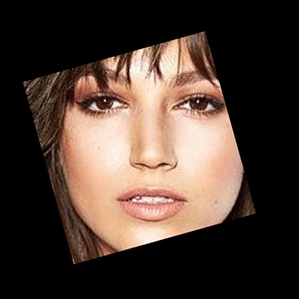

In [10]:
load_image(metadata[0].image_path())

#### VGG FACE CNN MODEL
-  Use to extract features

In [52]:
def vgg_face():
    """
    Create VGG Face model
    """
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Model Building
- Load the vgg face model
- Load the given weight file named "vgg_face_weights.h5"


In [54]:
# Create VGG Face Model to extract features
model = vgg_face()
model.load_weights('vgg_face_weights.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
# take layer except the last 2
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

##### Generate embeddings Vector for each image in the dataset

In [14]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
(2622,)


Create Embeddings For each image by calling predict on all metadata and store in embeddings

In [15]:
embeddings = np.zeros((metadata.shape[0], 2622))
for i in range(len(metadata)):
    img_path = metadata[i].image_path()
    print(i, metadata[i])
    img = load_image(img_path)
    img = (img / 255.).astype(np.float32)
    img = cv2.resize(img, dsize = (224, 224))

    #obtaining embedding vectors of all images
    embedding_vectors = vgg_face_descriptor.predict(np.expand_dims(img, axis = 0))[0]
    embeddings[i] = embedding_vectors



Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
8271 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch32.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
8272 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch18.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
8273 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch21.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
8274 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch36.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
8275 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch45.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
8276 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch34.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
8277 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch22.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
8278 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch16.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
8279 /content/PINS/pins_Thomas Middleditch/Thomas Middleditch2.

In [16]:
embedding_vector

array([ 0.01178132, -0.00278629,  0.01631491, ..., -0.0037676 ,
        0.0104393 ,  0.02431788], dtype=float32)

## Show Distance between pair of images


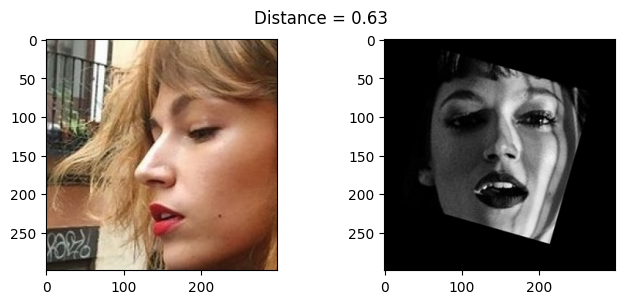

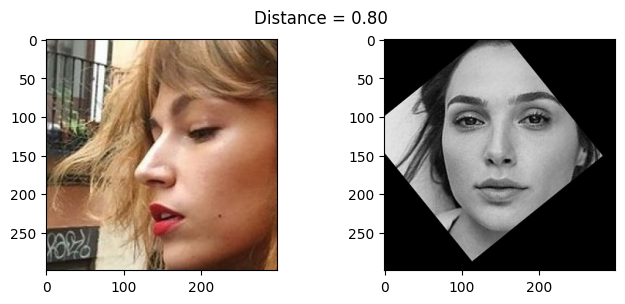

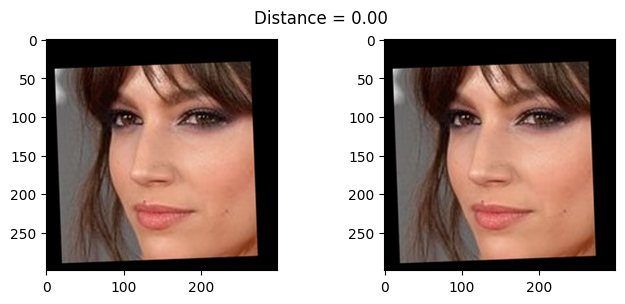

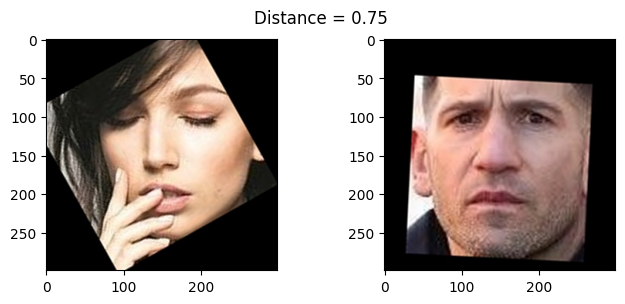

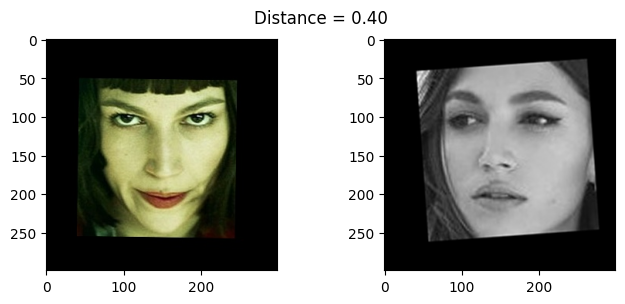

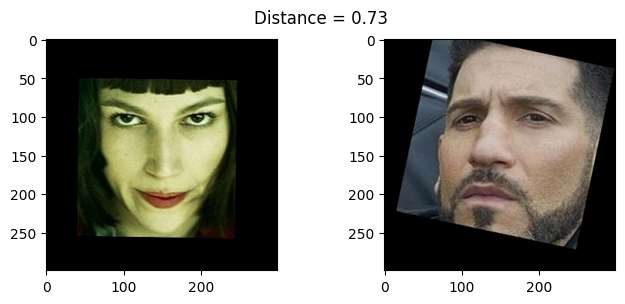

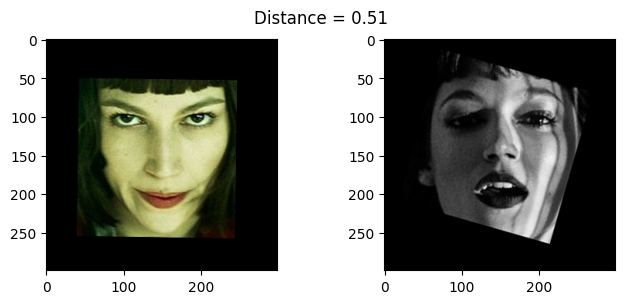

In [19]:
#Show distnace between pair of images
show_pair(2, 3)
show_pair(2, 180)
show_pair(31, 31)
show_pair(35, 100)
show_pair(75, 72)
show_pair(75, 115)
show_pair(75, 3)

### Q6
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [78]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0
test_idx = np.arange(metadata.shape[0]) % 9 == 0

# one half as train examples of 10 identities
X_train = embeddings[train_idx]
# another half as test examples of 10 identities
X_test = embeddings[test_idx]

targets = np.array([m.name for m in metadata])
y_train = targets[train_idx]
y_test = targets[test_idx]

- Encode the targets
- Use LabelEncoder

In [79]:
# Apply Label encoder
target = np.array([m.name for m in metadata])
enc = LabelEncoder()
enc.fit(target)

y = enc.transform(target)
y_train = y[train_idx]
y_test = y[test_idx]

- Scale the features using StandardScaler

In [80]:
# Standarize features
standard_scaler = StandardScaler()
# scale Xtrain with fit and trabsform
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.fit_transform(X_test)

#### Reduce feature dimensions using Principal Component Analysis
- Set the parameter n_components=128

In [81]:
# Apply PCA reduce dimensionality, speed up training, and remove noise
pca = PCA()

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

variance = pca.explained_variance_ratio_
print(variance)

[1.36206506e-01 5.38282321e-02 3.97404877e-02 ... 1.67716273e-09
 1.65126582e-09 9.19608637e-11]


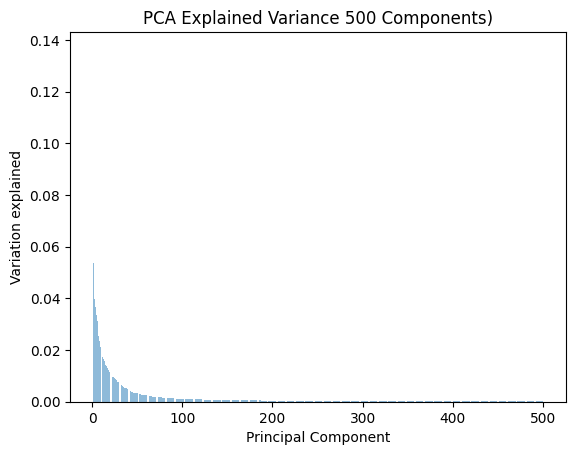

In [82]:
# Plot PCa varinace of first 500
plt.bar(range(1, 501), variance[:500], alpha=0.5, align='center')
plt.ylabel('Variation explained')
plt.xlabel('Principal Component')
plt.title('PCA Explained Variance 500 Components)')
plt.show()


### Observations:
After 150 It seems there is not much vraince values so we can train PCA wuith 150 components to save some compute

In [84]:
# SHow the shape
variance.shape

(2622,)

#### Build Classifier
- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score


In [83]:
# Create Support vector classifier and predict
svc = SVC(C = 1.0, kernel = 'rbf', gamma = 'auto')
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

In [85]:
print('Accuracy Score SVC Model is ', accuracy_score(y_test, svc_pred))

Accuracy Score SVC Model is  0.9598997493734336


### Observations:
Accurcay is 95% on test Data which is pretty good

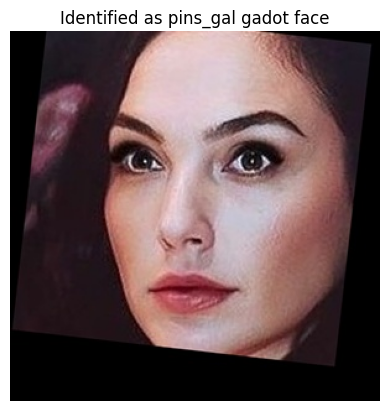

In [28]:
idx = 30

example_image = load_image(metadata[test_idx][idx].image_path())
show_identity_prediction(example_image,X_test[idx],svc, enc)

 ### Import and display test images

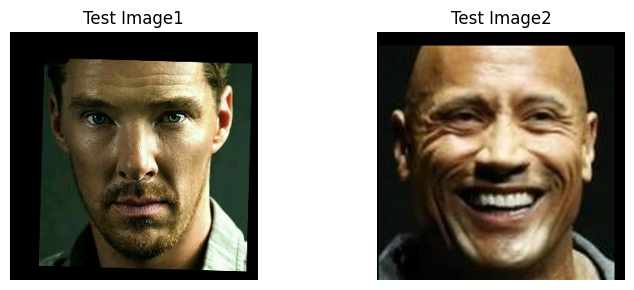

In [86]:
# load both images
test_image1 = load_image('/content/drive/MyDrive/Python Course_shared/computer Vision/Benedict Cumberbatch9.jpg')
test_image2 = load_image('/content/drive/MyDrive/Python Course_shared/computer Vision/Dwayne Johnson4.jpg')

# Plot both of the orginal ones
show_side_by_side_images(image1=test_image1,title1="Test Image1",title2="Test Image2",image2=test_image2)



In [34]:
# Normalize, Resize image1
image_1 = (test_image1 / 255.).astype(np.float32)
image_1 = cv2.resize(image_1, dsize = (224,224))
# creating embedding vectors for example images for model prediction
embedding_vector1 = vgg_face_descriptor.predict(np.expand_dims(image_1, axis=0))[0]

# Normalize, Resize image2
image_2 = (test_image2 / 255.).astype(np.float32)
image_2 = cv2.resize(image_2, dsize = (224,224))
# creating embedding vectors for example images for model prediction
embedding_vector2 = vgg_face_descriptor.predict(np.expand_dims(image_2, axis=0))[0]

# Reshape to size 2622 as thats the last layer size
embedding_vector1 = np.reshape(embedding_vector1, (1, 2622))
embedding_vector2 = np.reshape(embedding_vector2, (1, 2622))
print(f" embedding vector1 shape -->{embedding_vector1.shape} \n embedding vector2 shape -->{embedding_vector2.shape}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
 embedding vector1 shape -->(1, 2622) 
 embedding vector2 shape -->(1, 2622)


In [36]:
# Apply Scallr and PCA

embedding_vector_sc1 = standard_scaler.fit_transform(embedding_vector1)
embedding_vector_pca1 = pca.transform(embedding_vector_sc1)

embedding_vector_sc2 = standard_scaler.fit_transform(embedding_vector2)
embedding_vector_pca2 = pca.transform(embedding_vector_sc2)



In [93]:
# Predict and plot
y_pred_1 = svc.predict(embedding_vector_pca1)
y_pred_2 = svc.predict(embedding_vector_pca2)

print ('Prediction for Image 1 - Benedict Cumberbatch : ', y_pred_1)
print ('Prediction for Image 2 - Dwayne Johnson : ', y_pred_2)

Prediction for Image 1 - Benedict Cumberbatch :  [89]
Prediction for Image 2 - Dwayne Johnson :  [89]


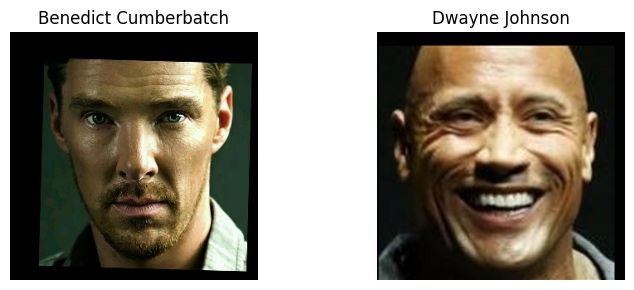

In [92]:
# Plot
if y_pred_1>50:
  title1='Benedict Cumberbatch'
else:
  title1='Unknown'

if y_pred_2>50:
  title2='Dwayne Johnson'
else:
  title2='Unknown'

show_side_by_side_images(image1=test_image1,title1=title1,image2=test_image2,title2=title2)